In [2]:
# -- Cell 1: Imports and data load --
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from data_loader import load_session, extract_lap_dataFrame

# Aesthetics — consistent across all project figures
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f6",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "monospace",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

COMPOUND_COLORS = {
    "SOFT":         "#E8383D",
    "MEDIUM":       "#F5C842",
    "HARD":         "#ECECEC",
    "INTERMEDIATE": "#4DC55A",
    "WET":          "#5B8BF5",
    "UNKNOWN":      "#AAAAAA",
}

session = load_session()
df_raw  = extract_lap_dataFrame(session)
print(df_raw.shape)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

Session loaded: Bahrain Grand Prix 2024
Total drivers: 20

Raw DataFrame shape: (1129, 12)
(1129, 12)


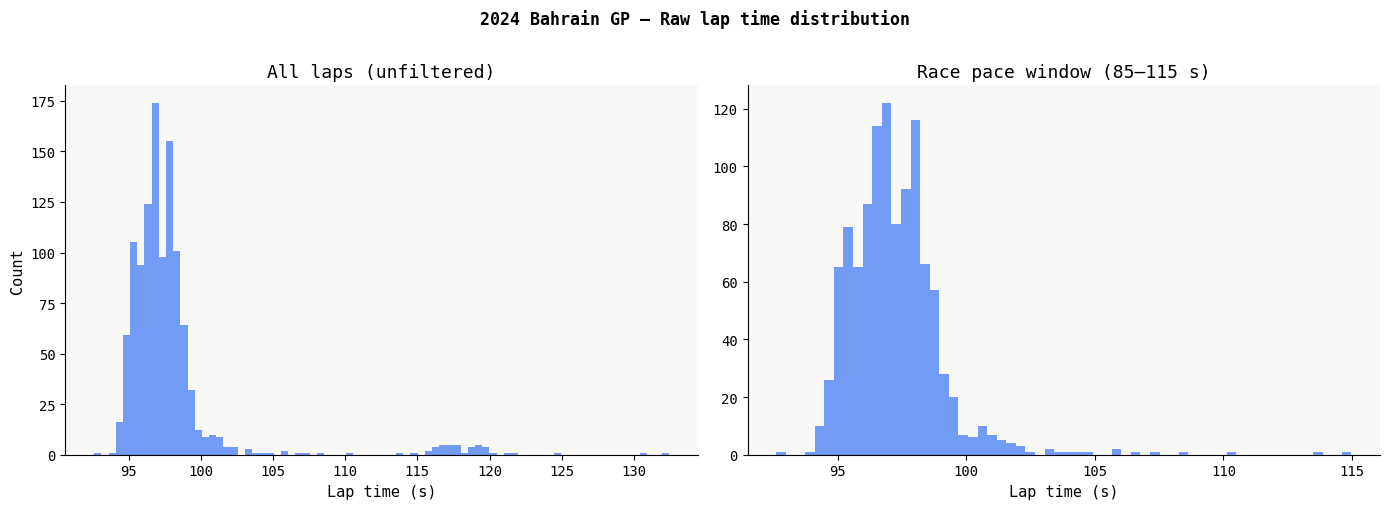

Laps outside race pace window: 43


In [3]:
# -- Cell 2: Raw lap time distribution — before any cleaning --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("2024 Bahrain GP — Raw lap time distribution", fontweight="bold", y=1.01)

# Left: full distribution to reveal outlier structure
axes[0].hist(df_raw["LapTimeSeconds"].dropna(), bins=80, color="#5B8BF5", edgecolor="none", alpha=0.85)
axes[0].set_xlabel("Lap time (s)")
axes[0].set_ylabel("Count")
axes[0].set_title("All laps (unfiltered)")

# Right: zoom to race pace window — this is where the story is
race_pace = df_raw[df_raw["LapTimeSeconds"].between(85, 115)]
axes[1].hist(race_pace["LapTimeSeconds"], bins=60, color="#5B8BF5", edgecolor="none", alpha=0.85)
axes[1].set_xlabel("Lap time (s)")
axes[1].set_title("Race pace window (85–115 s)")

plt.tight_layout()
plt.savefig("../reports/fig_01_raw_lap_dist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Laps outside race pace window: {len(df_raw) - len(race_pace)}")

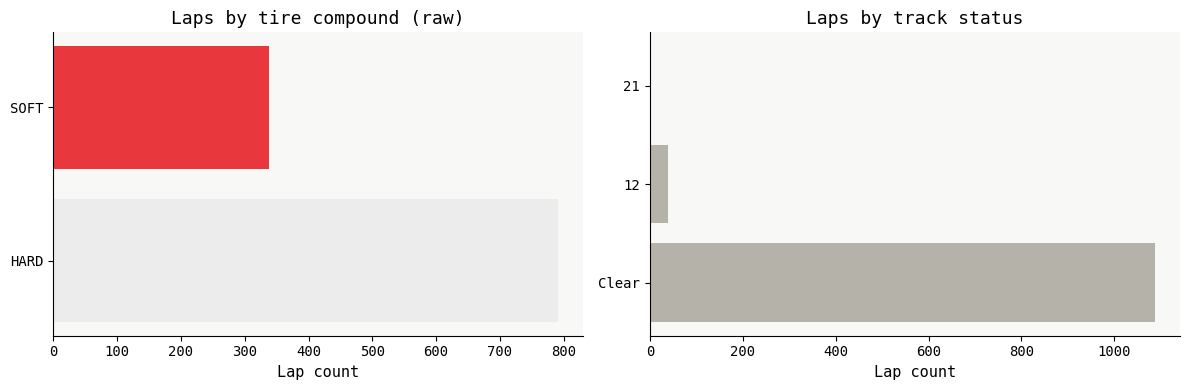

In [4]:
# -- Cell 3: Compound and TrackStatus audit --
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Compound breakdown
compound_counts = df_raw["Compound"].value_counts()
colors = [COMPOUND_COLORS.get(c, "#AAAAAA") for c in compound_counts.index]
axes[0].barh(compound_counts.index, compound_counts.values, color=colors, edgecolor="none")
axes[0].set_title("Laps by tire compound (raw)")
axes[0].set_xlabel("Lap count")

# TrackStatus breakdown — this tells us how many SC/VSC laps we need to filter
status_labels = {
    "1": "Clear",
    "2": "Yellow flag",
    "4": "Safety car",
    "5": "SC deployed",
    "6": "VSC",
    "7": "Red flag",
}
ts_counts = df_raw["TrackStatus"].value_counts()
ts_display = ts_counts.rename(index=lambda x: status_labels.get(str(x), str(x)))
axes[1].barh(ts_display.index, ts_display.values, color="#B4B2A9", edgecolor="none")
axes[1].set_title("Laps by track status")
axes[1].set_xlabel("Lap count")

plt.tight_layout()
plt.savefig("../reports/fig_02_compound_trackstatus.png", dpi=150, bbox_inches="tight")
plt.show()

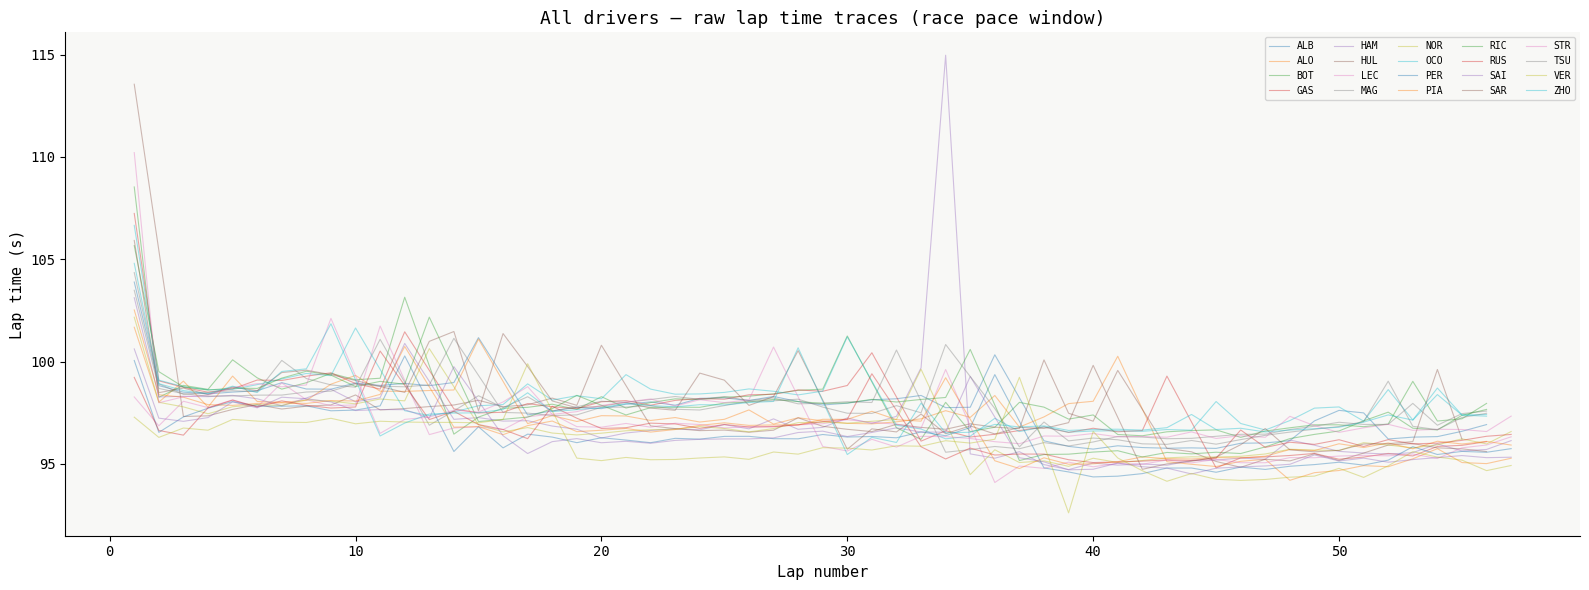

In [5]:
# -- Cell 4: Quick per-driver lap time trace — see the shape of the race --
pivot = df_raw.dropna(subset=["LapTimeSeconds"])
pivot = pivot[pivot["LapTimeSeconds"].between(85, 115)]

fig, ax = plt.subplots(figsize=(16, 6))
for driver, group in pivot.groupby("Driver"):
    ax.plot(group["LapNumber"], group["LapTimeSeconds"],
            alpha=0.4, linewidth=0.8, label=driver)

ax.set_xlabel("Lap number")
ax.set_ylabel("Lap time (s)")
ax.set_title("All drivers — raw lap time traces (race pace window)")
ax.legend(ncol=5, fontsize=7, loc="upper right")
plt.tight_layout()
plt.savefig("../reports/fig_03_raw_traces.png", dpi=150, bbox_inches="tight")
plt.show()